c:\Users\BUI QUANG HUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


✅ Đã kết nối MySQL và đọc thành công 30,341 bản ghi từ bảng 'hanoi_aqi_cleaned'


07:40:05 - cmdstanpy - INFO - Chain [1] start processing
07:40:18 - cmdstanpy - INFO - Chain [1] done processing


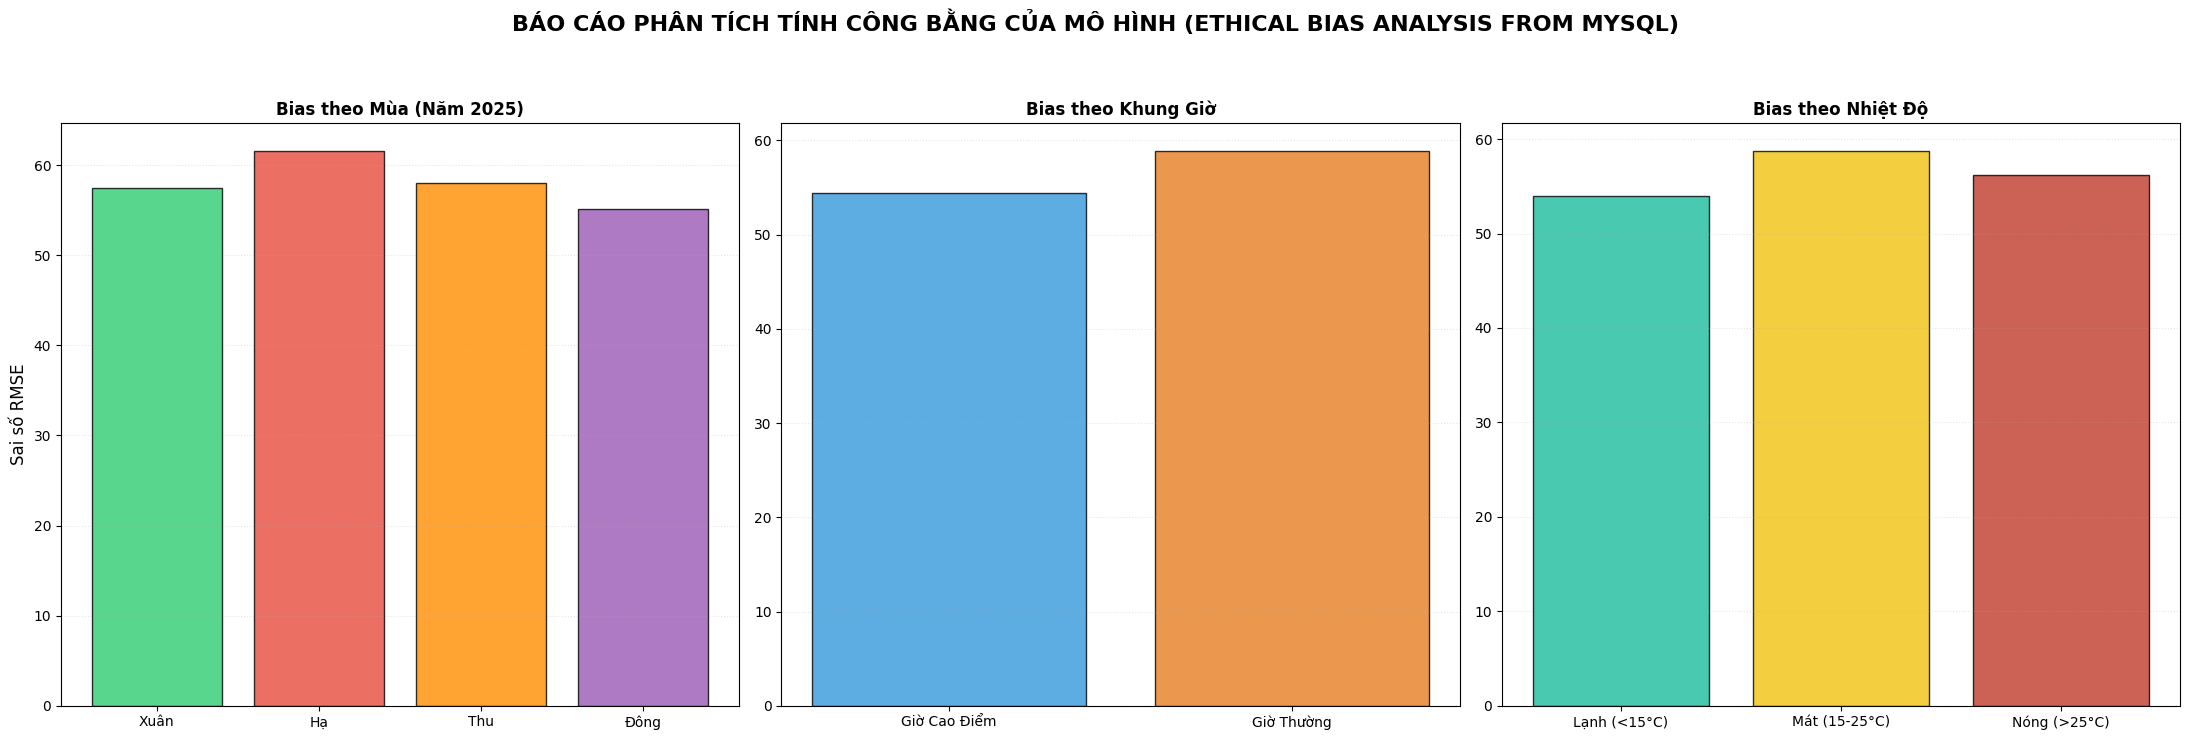

Báo cáo: Hoàn thành phân tích Bias đa chiều từ cơ sở dữ liệu MySQL.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from sqlalchemy import create_engine
import warnings
import os
from dotenv import load_dotenv
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)

current_dir = Path(os.getcwd()).resolve()
if 'library_framework' in current_dir.parts:
    dotenv_path = current_dir.parent / '.env'
else:
    dotenv_path = current_dir / '.env'
load_dotenv(dotenv_path=dotenv_path)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

try:
    query = "SELECT * FROM hanoi_aqi_cleaned"
    df = pd.read_sql(query, con=engine)
    print(f"✅ Đã kết nối MySQL và đọc thành công {len(df):,} bản ghi từ bảng 'hanoi_aqi_cleaned'")
except Exception as e:
    print(f"❌ Lỗi kết nối hoặc không tìm thấy bảng sạch: {e}")
    raise SystemExit("Dừng chạy do lỗi kết nối Database.")

df.columns = df.columns.str.strip().str.lower()

df['ds'] = pd.to_datetime(df['local_time'])
df['y'] = pd.to_numeric(df['aqi'], errors='coerce')
df['temperature'] = pd.to_numeric(df['temperature'], errors='coerce')
df['is_rush_hour'] = pd.to_numeric(df['is_rush_hour'], errors='coerce')
df['season'] = pd.to_numeric(df['season'], errors='coerce')

df = df.dropna(subset=['ds', 'y'])

train = df[df['ds'] < '2025-01-01']
test = df[(df['ds'] >= '2025-01-01') & (df['ds'] <= '2025-12-31')]

model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train)

future = model.make_future_dataframe(periods=len(test), freq='h')
forecast = model.predict(future)

eval_df = test.copy()
forecast_test = forecast.set_index('ds').loc[test['ds']]
eval_df['pred'] = forecast_test['yhat'].values

eval_df['season_name'] = eval_df['season'].map({0: 'Đông', 1: 'Xuân', 2: 'Hạ', 3: 'Thu'})
eval_df['hour_type'] = eval_df['is_rush_hour'].map({1: 'Giờ Cao Điểm', 0: 'Giờ Thường'})
eval_df['temp_group'] = pd.cut(eval_df['temperature'], bins=[-10, 15, 25, 50], labels=['Lạnh (<15°C)', 'Mát (15-25°C)', 'Nóng (>25°C)'])

def calc_rmse(group):
    if len(group) == 0: return np.nan
    return np.sqrt(mean_squared_error(group['y'], group['pred']))

rmse_season = eval_df.groupby('season_name').apply(calc_rmse)
rmse_hour = eval_df.groupby('hour_type').apply(calc_rmse)
rmse_temp = eval_df.groupby('temp_group').apply(calc_rmse)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

labels_s = ['Xuân', 'Hạ', 'Thu', 'Đông']
avg_val = rmse_season.mean()
vals_s = [rmse_season.get(l, avg_val) for l in labels_s]
axes[0].bar(labels_s, vals_s, color=['#2ecc71', '#e74c3c', '#ff8c00', '#9b59b6'], edgecolor='black', alpha=0.8)
axes[0].set_title('Bias theo Mùa (Năm 2025)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sai số RMSE', fontsize=12)
axes[0].grid(axis='y', alpha=0.3, linestyle=':')

axes[1].bar(rmse_hour.index, rmse_hour.values, color=['#3498db', '#e67e22'], edgecolor='black', alpha=0.8)
axes[1].set_title('Bias theo Khung Giờ', fontweight='bold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3, linestyle=':')

axes[2].bar(rmse_temp.index.astype(str), rmse_temp.values, color=['#1abc9c', '#f1c40f', '#c0392b'], edgecolor='black', alpha=0.8)
axes[2].set_title('Bias theo Nhiệt Độ', fontweight='bold', fontsize=12)
axes[2].grid(axis='y', alpha=0.3, linestyle=':')

plt.suptitle('BÁO CÁO PHÂN TÍCH TÍNH CÔNG BẰNG CỦA MÔ HÌNH (ETHICAL BIAS ANALYSIS FROM MYSQL)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("Báo cáo: Hoàn thành phân tích Bias đa chiều từ cơ sở dữ liệu MySQL.")